## Counterfactuals generation for C2019-05 Fuel Tank Filter 

Sneak peak of the project

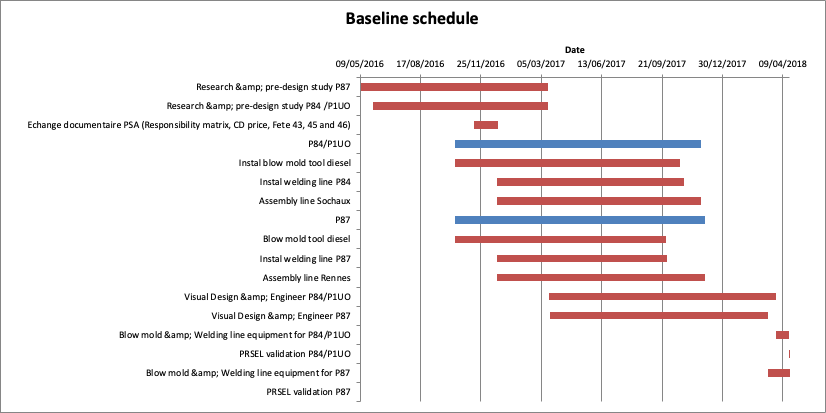
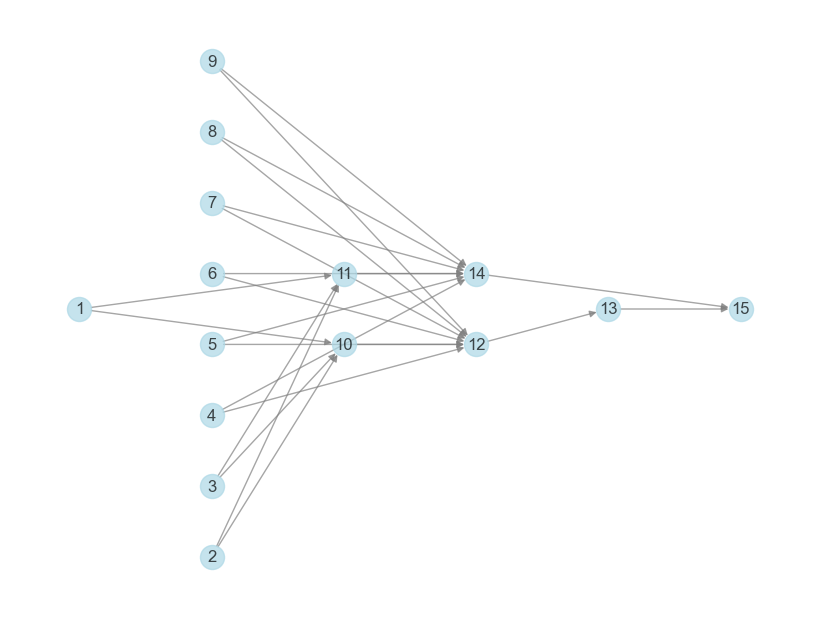
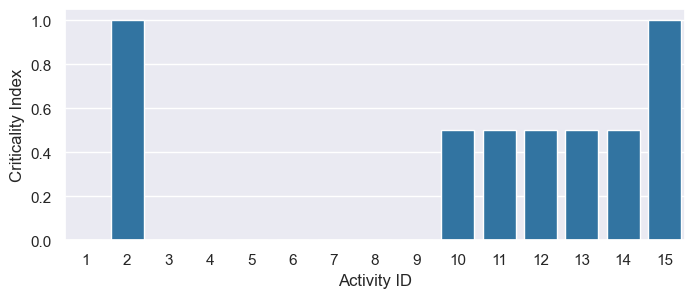

### **Flujo de Actividades del Proyecto**  

#### **1. Investigación y Pre-diseño**  
1. **Research & pre-design study P87** – Análisis técnico y económico del diseño P87.  
2. **Research & pre-design study P84/P1UO** – Evaluación del diseño P84/P1UO.  
3. **Echange documentaire PSA** – Gestión documental y coordinación entre equipos.  

#### **2. Instalaciones de Producción**  
4. **Molde de soplado diésel** – Instalación del equipo para fabricar tanques de combustible.  
5. **Línea de soldadura P84** – Implementación de la línea de soldadura del modelo P84.  
6. **Línea de ensamblaje Sochaux** – Habilitación de la línea de ensamblaje en Sochaux.  
7. **Molde de soplado P87** – Instalación del equipo para la producción del modelo P87.  
8. **Línea de soldadura P87** – Implementación de la línea de soldadura del modelo P87.  
9. **Línea de ensamblaje Rennes** – Habilitación de la línea de ensamblaje en Rennes.  

#### **3. Diseño Visual e Ingeniería**  
10. **Visual Design & Engineer P84/P1UO** – Desarrollo y validación técnica del diseño P84/P1UO.  
11. **Visual Design & Engineer P87** – Desarrollo y validación técnica del diseño P87.  

#### **4. Validaciones Finales y Pruebas**  
12. **Molde de soplado & línea de soldadura P84/P1UO** – Pruebas de producción para el modelo P84/P1UO.  
13. **Validación PRSEL P84/P1UO** – Certificación final del modelo P84/P1UO.  
14. **Molde de soplado & línea de soldadura P87** – Pruebas de producción para el modelo P87.  
15. **Validación PRSEL P87** – Certificación final del modelo P87.  

El proyecto sigue un flujo secuencial: **investigación → implementación → diseño final → validación**, asegurando la viabilidad del producto antes de la producción en serie.  


In [97]:
# DiCE imports
import dice_ml
from dice_ml.utils import helpers  # helper functions

# pandas and numpy
import pandas as pd
import numpy as np

#TF imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import backend as K
K.set_image_data_format('channels_first') ## Trying to solve NN overflow issue

# others
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import random

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [98]:

def normalize_dataframe(df, feature_range=(0, 1)):
    """
    Normaliza un DataFrame de pandas utilizando MinMaxScaler.

    Args:
        df (pd.DataFrame): DataFrame a normalizar.
        feature_range (tuple): Rango de valores para la normalización (por defecto (0, 1)).

    Returns:
        pd.DataFrame: DataFrame normalizado.
        MinMaxScaler: Escalador utilizado para la normalización.
    """
    scaler = MinMaxScaler(feature_range=feature_range)
    normalized_data = scaler.fit_transform(df)
    normalized_df = pd.DataFrame(normalized_data, columns=df.columns, index=df.index)
    return normalized_df, scaler

def denormalize_dataframe(normalized_df, scaler):
    """
    Desnormaliza un DataFrame de pandas utilizando un MinMaxScaler previamente ajustado.

    Args:
        normalized_df (pd.DataFrame): DataFrame normalizado.
        scaler (MinMaxScaler): Escalador utilizado para la normalización.

    Returns:
        pd.DataFrame: DataFrame desnormalizado.
    """
    denormalized_data = scaler.inverse_transform(normalized_df)
    denormalized_df = pd.DataFrame(denormalized_data, columns=normalized_df.columns, index=normalized_df.index)
    return denormalized_df

In [99]:
from sklearn.preprocessing import MinMaxScaler

# Dataset
data=pd.read_csv('./data/C201905_counterfactuals/simulation_C201905_counterfactuals__ev0.1812.csv',index_col=0)
data['delay']=(data['actual_duration']>data['baseline_duration'])*1
data.drop(columns=['actual_duration','baseline_duration','critical_path'],inplace=True)
data.head(4)

# Ordenar las columnas de data por el número al lado de "duration"
columns_sorted = sorted(data.columns, key=lambda x: int(x.replace('duration', '')) if 'duration' in x else float('inf'))
data = data[columns_sorted]
data.head(4)

# Remove duration1 and duration15 as they are starting and finishing points with no variation
#data.drop(columns=['duration1', 'duration15'], inplace=True)
#data.head(4)

,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1738.595774,1967.122966,256.504345,2186.408241,1723.181771,1898.648645,1795.289433,1599.760892,2224.382275,2489.048379,2124.279759,139.271436,8.498099,234.542254,7.655393,1
1,1717.864331,1881.352898,266.048082,2324.022291,1849.728508,2083.309016,1839.782891,1593.929687,2323.598219,2279.745524,2334.495021,145.448900,8.235859,238.908956,8.357302,1
2,1723.565743,1938.317701,258.077112,2231.376065,1963.453894,1728.135131,1695.630774,1743.449586,2076.795075,2519.823225,2064.467610,141.045832,8.062166,224.413934,8.258951,1
3,1682.927264,1878.207068,266.893569,2141.395086,1956.932514,2089.589342,1856.719488,1922.201739,2130.739319,2182.469780,2212.950615,143.330792,7.725884,245.122682,8.908782,0


In [100]:
# Normalize the dataset to improve the performance of the neural network

data_to_normalize = data.iloc[:, :-1]  # Select all columns except the last one
normalized_data, my_scaler = normalize_dataframe(data_to_normalize)
data = pd.concat([normalized_data, data.iloc[:, -1]], axis=1)  # Combine normalized data with the last column

data.head(10)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.751643,0.821171,0.653332,0.547362,0.393468,0.432562,0.715566,0.442461,0.804429,0.891496,0.551165,0.700622,0.641918,0.698465,0.380315,1
1,0.675055,0.594889,0.759338,0.713173,0.582989,0.679778,0.789338,0.432862,0.938094,0.637179,0.819892,0.830761,0.556337,0.752252,0.604439,1
2,0.696118,0.745176,0.670802,0.601544,0.753309,0.204285,0.550328,0.679006,0.605597,0.928890,0.474704,0.738003,0.499653,0.573710,0.573035,1
3,0.545988,0.586590,0.768729,0.493126,0.743542,0.688186,0.817419,0.973274,0.678271,0.518982,0.664516,0.786140,0.389908,0.828789,0.780530,0
4,0.797080,0.657900,0.776355,0.682543,0.796596,0.629967,0.416572,0.627376,0.695928,0.443811,0.545223,0.719830,0.922303,0.811485,0.788655,0
5,0.869145,0.818320,0.705269,0.714043,0.553619,0.449203,0.440842,0.616881,0.413094,0.662586,0.280634,0.351965,0.542156,0.654795,0.512055,1
6,0.608801,0.370410,0.881106,0.370134,0.762450,0.520021,0.430433,0.564377,0.748438,0.243504,0.850541,0.764217,0.815221,0.743533,0.377688,1
7,0.697262,0.844057,0.828432,0.890418,0.712821,0.591340,0.759104,0.311473,0.498398,0.861929,0.405843,0.925666,0.667969,0.654865,0.222582,1
8,0.493139,0.238946,0.844519,0.813926,0.808740,0.776539,0.739539,0.796945,0.671279,0.945056,0.676480,0.605017,0.608484,0.808672,0.947563,1
9,0.526056,0.462148,0.547075,0.847107,0.868212,0.726655,0.616591,0.315824,0.513370,0.457637,0.731409,0.817011,0.778830,0.425375,0.670752,0


In [101]:
# Split the dataset into features and class
X = data.drop(columns=['delay'])
y = data['delay']

# Se usa stratify=y en train_test_split para asegurar que la distribución de clases sea la misma en entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verificar la distribución de clases (me están saliendo accuracies de 1 xq sólo tenemos datos con retraso)
print("Unique labels in training:", np.unique(y_train, return_counts=True))
print("Unique labels in test:", np.unique(y_test, return_counts=True))

Unique labels in training: (array([0, 1]), array([ 5564, 14436]))
Unique labels in test: (array([0, 1]), array([1391, 3609]))


### Modelo con TensorFLow

In [102]:
# ---- Modelo con TensorFlow ----
def build_model(hp):
    model = keras.Sequential([
        layers.Dense(hp.Int('units', min_value=32, max_value=128, step=32), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        #layers.Dropout(0.5),  # Agrega Dropout
        layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [0.01, 0.001, 0.0001])),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

from kerastuner.tuners import RandomSearch
tuner = RandomSearch(build_model, objective='val_accuracy', max_trials=10, executions_per_trial=1, directory='tuner_dir')

tuner.search(X_train, y_train, epochs=30, validation_split=0.2, batch_size=32)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best TensorFlow Model: units={best_hps.get('units')}, learning_rate={best_hps.get('learning_rate')}")

# Evaluación final con los mejores hiperparámetros
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
test_loss, test_acc = best_model.evaluate(X_test, y_test)

print("Best TensorFlow Accuracy:", test_acc)
# Guardar el modelo
best_model.save('best_model.h5')
# Cargar el modelo
loaded_model = keras.models.load_model('best_model.h5')
# Predecir
predictions = loaded_model.predict(X_test)
predictions = np.argmax(predictions, axis=1)
# Verificar la precisión
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print("Accuracy of loaded model:", accuracy)


Reloading Tuner from tuner_dir/untitled_project/tuner0.json
Best TensorFlow Model: units=128, learning_rate=0.001
Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 574us/step - accuracy: 0.7348 - loss: 0.6541 - val_accuracy: 0.8428 - val_loss: 0.4113
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - accuracy: 0.8394 - loss: 0.4032 - val_accuracy: 0.8597 - val_loss: 0.3512
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - accuracy: 0.8519 - loss: 0.3559 - val_accuracy: 0.8620 - val_loss: 0.3253
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.8592 - loss: 0.3326 - val_accuracy: 0.8645 - val_loss: 0.3123
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - accuracy: 0.8620 - loss: 0.3201 - val_accuracy: 0.8643 - val_loss: 0.3054
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - accuracy: 0.8643 - loss: 0.3134 - val_accuracy: 0.8655 - val_loss: 0.3014
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step - accuracy: 0.8660 - loss: 0.3093 - val_accuracy: 0.

Best TensorFlow Accuracy: 0.9768000245094299
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 308us/step
Accuracy of loaded model: 0.9768


In [103]:
print(X_test[1:2])
print(y_test[1:2])

       duration1  duration2  duration3  duration4  duration5  duration6  \
18644   0.360323   0.531061   0.938993   0.464478   0.417879   0.470381   

       duration7  duration8  duration9  duration10  duration11  duration12  \
18644   0.611009   0.406011   0.632609    0.885625    0.873375    0.601832   

       duration13  duration14  duration15  
18644    0.951708    0.305983     0.33946  
18644    1
Name: delay, dtype: int64


In [104]:
 #construct a data object for DiCE. 
d = dice_ml.Data(dataframe=data, continuous_features=['duration1', 'duration2', 'duration3', 'duration4', 'duration5', 
                                                      'duration6', 'duration7', 'duration8', 'duration9', 'duration10', 
                                                      'duration11', 'duration12', 'duration13', 'duration14', 'duration15'], 
                 outcome_name='delay')
 

# initialize the model
m = dice_ml.Model(model=loaded_model, backend="TF2") 

## CFs método random (muy rápido)

In [105]:
# initiate the DiCE explainer, which needs a dataset and a model. 
exp_random = dice_ml.Dice(data_interface=d, model_interface=m, method="random")

mis_CFs_random = exp_random.generate_counterfactuals(X_test[1:2], total_CFs=10, desired_class="opposite")
mis_CFs_random.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  1.83it/s]

Query instance (original outcome : 1)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.360323,0.531061,0.938993,0.464478,0.417879,0.470381,0.611009,0.406011,0.632609,0.885625,0.873375,0.601832,0.951708,0.305983,0.33946,1



Diverse Counterfactual set (new outcome: 0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,-,0.06817231,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
1,-,0.08698676,-,-,-,-,-,-,-,-,-,-,0.26935692,-,-,0.0
2,-,-,-,-,-,-,-,-,-,0.24219589,0.5878857,-,-,-,-,0.0
3,-,0.03252618,-,-,-,-,-,0.86277079,-,-,-,-,-,-,-,0.0
4,-,0.04010919,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
5,-,0.07319592,-,-,-,-,-,-,0.93857825,-,-,-,-,-,-,0.0
6,0.929376,0.13252467,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
7,-,0.00638587,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
8,-,0.00756288,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
9,-,-,-,-,-,-,-,-,-,0.72697988,0.54536286,-,-,-,-,0.0


In [106]:
from IPython.core.display import display


# Desnormalizar X_test[1:2]
my_query_desnormalized = denormalize_dataframe(X_test[1:2], my_scaler)

# Combinar X_test[1:2] y y_test[1:2] en un solo DataFrame para desnormalizarlos juntos
my_query = pd.concat([my_query_desnormalized.reset_index(drop=True), y_test[1:2].reset_index(drop=True)], axis=1)

print("intancia de origen")
print(my_query)

# desnormalizo los CFs
mis_CFs_random_desnormalized = denormalize_dataframe(mis_CFs_random.cf_examples_list[0].final_cfs_df.iloc[:, :-1], my_scaler)
mis_CFs_random_desnormalized['delay'] = mis_CFs_random.cf_examples_list[0].final_cfs_df.iloc[:, -1].values

print("\n counterfactuals encontrados")
print(mis_CFs_random)

# Crear un DataFrame comparativo
comparison_df = mis_CFs_random_desnormalized.copy()
for col in my_query_desnormalized.columns:
    comparison_df[f"{col}_change_%"] = ((mis_CFs_random_desnormalized[col] - my_query_desnormalized[col].values[0]) / my_query_desnormalized[col].values[0]) * 100

    # Keep only columns with '_change_%' in their names
    comparison_df = comparison_df[[col for col in comparison_df.columns if '_change_%' in col]]

    # Replace NaN values with 0
    comparison_df.fillna(0, inplace=True)

# Print all colums in the same row of my windows
pd.set_option('display.max_columns', None)
# Add a column to mark changes in  color 
comparison_df_styled = comparison_df.style.applymap(
    lambda x: f"color: white;" if x != 0 else "color: grey;"
)

# Display the styled DataFrame
print("\n Comparación entre la instancia de origen y los CFs encontrados")
display(comparison_df_styled.format("{:.2f}")) 

intancia de origen
     duration1    duration2   duration3    duration4    duration5  \
0  1632.669507  1857.159461  282.222504  2117.618985  1739.481539   

     duration6    duration7    duration8    duration9   duration10  \
0  1926.898447  1732.228628  1577.619514  2096.845475  2484.216599   

    duration11  duration12  duration13  duration14  duration15  delay  
0  2376.333018  134.582034    9.447363  202.678308    7.527444      1  

 counterfactuals encontrados

 Comparación entre la instancia de origen y los CFs encontrados


/var/folders/gm/dmfb8b7n71jgq4nczfq076s40000gn/T/ipykernel_31292/930654195.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
0,0.00,-9.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,-9.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-22.13,0.00,0.00
2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-21.32,-9.40,0.00,0.00,0.00,0.00
3,0.00,-10.17,0.00,0.00,0.00,0.00,0.00,17.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,-10.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,-9.34,0.00,0.00,0.00,0.00,0.00,0.00,10.83,0.00,0.00,0.00,0.00,0.00,0.00
6,9.43,-8.13,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,0.00,-10.71,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,0.00,-10.68,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
9,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-5.26,-10.80,0.00,0.00,0.00,0.00


## CFs con Gradient based Method. Mothilal et al. (2020)


In [107]:
# initiate the DiCE explainer, which needs a dataset and a model. 
exp_gradient = dice_ml.Dice(data_interface=d, model_interface=m, method='gradient')

dice_exp = exp_gradient.generate_counterfactuals(X_test[1:2], total_CFs=10, desired_class="opposite")
dice_exp.visualize_as_dataframe(show_only_changes=True)



#mis_CFs = exp_gradient.generate_counterfactuals(X_test[1:2], total_CFs=5, desired_class="opposite", 
                                                #features_to_vary=['duration2', 'duration3', 'duration4', 'duration5', 'duration6', 'duration7', 'duration8', 'duration9', 'duration10', 'duration11', 'duration12', 'duration13', 'duration14'],
                                                #permitted_range={feature: [0, 1] for feature in ['duration1','duration2', 'duration3', 'duration4', 'duration5', 'duration6', 'duration7', 'duration8', 'duration9', 'duration10', 'duration11', 'duration12', 'duration13', 'duration14','duration15']}
                                                #)
#mis_CFs.visualize_as_dataframe(show_only_changes=True)

Diverse Counterfactuals found! total time taken: 01 min 00 sec
Query instance (original outcome : 1.0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.360323,0.531061,0.938993,0.464478,0.417879,0.470381,0.611009,0.406011,0.632609,0.885625,0.873375,0.601832,0.951708,0.305983,0.33946,1.0



Diverse Counterfactual set (new outcome: 0.0)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,0.36086857318878174,0.2822265326976776,0.949758427047227,0.4656007455826332,0.08051250874996185,0.5129036903381348,0.6067876649861592,0.4268971847534706,0.6214102936749715,0.5145909190177917,0.6785351037979126,0.46341627836227417,0.8987656831741333,0.4429064095020294,0.32187540626528754,0.0
1,0.3501508368014763,0.3116041123867035,0.5595877766609192,0.4487402273177574,0.42957846989636916,0.48319111933713454,0.6217693256373149,0.43597957491874695,0.6361209916109782,0.32438209652900696,0.29401132464408875,0.6127801703448039,0.921893298625946,0.0,0.3463097085952471,0.0
2,0.3435595763682793,0.32925182580947876,0.9572661088938457,0.4388965368270874,0.4079610539435814,0.4634386135100792,0.624778346919511,0.3729720413684845,0.6217905117039937,0.6529382467269897,0.4281880259513855,0.09227543324232101,0.8283127546310425,0.04288598150014877,0.33548788523676887,0.0
3,0.5060504674911499,0.02563158981502056,0.9464925693506938,0.4159405529499054,0.5325093865394592,0.4273700416088104,0.5865133238797444,0.38930494914049607,0.6420181559557658,0.744600772857666,0.8781145380968791,0.5814137292866963,0.9879183769226074,0.29646687040323716,0.33982470631599426,0.0
4,0.38712891936302185,0.5335652994150859,0.9350553585057515,0.45710654387468797,0.4198023246765663,0.5616685152053833,0.5661020278930664,0.3933666480540703,0.5831173062324524,0.2442152500152588,0.1366279572248459,0.6185233758921367,0.9704571532244426,0.3178309666157295,0.32823858952525153,0.0
5,0.3768772350788643,0.0,0.9356112910275716,0.43856844305992126,0.43653480877881545,0.48985119333272475,0.6131639050478679,0.4033957851886223,0.5941367745399475,0.9232316613197327,0.4276535212993622,0.6078260706896526,0.9548033045763713,0.0003664199903141707,0.08330409973859787,0.0
6,0.35399029979700547,0.5969902276992798,0.9707292318344116,0.4609505070208977,0.4058543575763176,0.475407557392173,0.6079966259961385,0.23545432090759277,0.9381184577941895,0.6329538822174072,0.4093410074710846,0.5924488736157674,0.9587276147837382,0.31480045785909194,0.3743661940097809,0.0
7,0.3603615164756775,0.19713932275772095,0.9322503043179768,0.4767635928631355,0.42752681841855544,0.477407114410453,0.9255945086479187,0.3893942368983696,0.6189563704495686,0.376349538564682,0.38455209136009216,0.39235228300094604,0.9470866752629536,0.32352967729573745,0.3694312870502472,0.0
8,0.07047487050294876,0.08180438727140427,0.9307381344800252,0.5142106413841248,0.41543267498011094,0.4656603766440819,0.6167825626368266,0.40827243199353713,0.621461374855544,0.4419029653072357,0.8529174161916036,0.5937617851262349,0.9315590692525166,0.3301194178104927,0.30261579155921936,0.0
9,0.35584048757547837,0.0,1.0,0.5116106867790222,0.38829663395881653,0.15311197936534882,0.5795505046844482,0.44624316692352295,0.6582811640734416,0.6870489120483398,0.3889266550540924,0.7412596940994263,1.0,0.10488805174827576,0.33295209503176704,0.0


In [109]:
from IPython.core.display import display


# Desnormalizar X_test[1:2]
my_query_desnormalized = denormalize_dataframe(X_test[1:2], my_scaler)

# Combinar X_test[1:2] y y_test[1:2] en un solo DataFrame para desnormalizarlos juntos
my_query = pd.concat([my_query_desnormalized.reset_index(drop=True), y_test[1:2].reset_index(drop=True)], axis=1)

print("intancia de origen")
print(my_query)

# desnormalizo los CFs
mis_CFs_desnormalized = denormalize_dataframe(mis_CFs.cf_examples_list[0].final_cfs_df.iloc[:, :-1], my_scaler)
mis_CFs_desnormalized['delay'] = mis_CFs.cf_examples_list[0].final_cfs_df.iloc[:, -1].values

print("\n counterfactuals encontrados")
print(mis_CFs_desnormalized)

# Crear un DataFrame comparativo
comparison_df = mis_CFs_desnormalized.copy()
for col in my_query_desnormalized.columns:
    comparison_df[f"{col}_change_%"] = ((mis_CFs_desnormalized[col] - my_query_desnormalized[col].values[0]) / my_query_desnormalized[col].values[0]) * 100

    # Keep only columns with '_change_%' in their names
    comparison_df = comparison_df[[col for col in comparison_df.columns if '_change_%' in col]]

    # Replace NaN values with 0
    comparison_df.fillna(0, inplace=True)

# Print all colums in the same row of my windows
pd.set_option('display.max_columns', None)
# Add a column to mark changes in  color 
comparison_df_styled = comparison_df.style.applymap(
    lambda x: f"color: white;" if x != 0 else "color: grey;"
)

# Display the styled DataFrame
print("\n Comparación entre la instancia de origen y los CFs encontrados")
display(comparison_df_styled.format("{:.2f}")) 

intancia de origen
     duration1    duration2   duration3    duration4    duration5  \
0  1632.669507  1857.159461  282.222504  2117.618985  1739.481539   

     duration6    duration7    duration8    duration9   duration10  \
0  1926.898447  1732.228628  1577.619514  2096.845475  2484.216599   

    duration11  duration12  duration13  duration14  duration15  delay  
0  2376.333018  134.582034    9.447363  202.678308    7.527444      1  

 counterfactuals encontrados
     duration1    duration2   duration3    duration4    duration5  \
0  1632.669507  1692.295490  282.222504  2117.618985  1739.481539   
1  1632.669507  1709.446624  282.222504  2117.618985  1739.481539   
2  1632.669507  1676.013329  254.112861  2117.618985  1739.481539   
3  1632.669507  1676.013329  282.222504  2117.618985  1739.481539   
4  1632.669507  1664.926868  282.222504  2215.667855  1739.481539   
5  1632.669507  1748.490221  282.222504  2117.618985  1739.481539   
6  1619.238264  1657.624832  282.222504  211

/var/folders/gm/dmfb8b7n71jgq4nczfq076s40000gn/T/ipykernel_31292/3866216852.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display


,duration1_change_%,duration2_change_%,duration3_change_%,duration4_change_%,duration5_change_%,duration6_change_%,duration7_change_%,duration8_change_%,duration9_change_%,duration10_change_%,duration11_change_%,duration12_change_%,duration13_change_%,duration14_change_%,duration15_change_%
0,0.00,-8.88,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-25.99,0.00,0.00
1,0.00,-7.95,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,-9.75,-9.96,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,-9.75,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,-10.35,0.00,4.63,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,-5.85,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.21,0.00,0.00,0.00,0.00,0.00
6,-0.82,-10.74,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,1.94,-10.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-10.94,-18.21,0.00,0.00,0.00,0.00
9,0.00,-8.21,0.00,0.00,0.00,-15.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
